# Question 4 : Variational Autoencoder

## Question 4.1 : Introduction

The advantage of VAEs over traditional AEs is having a continuous and more interpretable latent space. This is achieved by treating the posterior P(z|x) as a gaussian and trying to minimize the KL divergence with the latent space distribution which is assumed to be N(0, 1) along with a data consistency loss as well such as BCE or MSE. While a small KL divergence keeps the space from developing any gaps, the data consistency term avoids too close locality of the classes.

The basic idea behind the VAE proposed by Kingma et al in 2013 is that instead of mapping an input to a fixed vector, the input is mapped to a distribution.

### Mathematical Foundation of VAEs


In generative modeling, we want to learn the distribution $p_\theta(x)$ of our data $x$. VAEs introduce latent variables $z$ and model the joint distribution:

$$p_\theta(x, z) = p_\theta(x|z)p(z)$$

where:
- $p(z) = \mathcal{N}(0, I)$ is the prior (standard normal)
- $p_\theta(x|z)$ is the decoder/generative model

The true posterior $p_\theta(z|x) = \frac{p_\theta(x|z)p(z)}{p_\theta(x)}$ is intractable because computing $p_\theta(x) = \int p_\theta(x|z)p(z)dz$ requires integrating over all possible $z$.

VAEs use **variational inference** to approximate the intractable posterior with a simpler distribution $q_\phi(z|x)$ (the encoder):

$$q_\phi(z|x) = \mathcal{N}(z; \mu_\phi(x), \sigma^2_\phi(x)I)$$

We minimize the KL divergence between $q_\phi(z|x)$ and $p_\theta(z|x)$:

$$D_{KL}(q_\phi(z|x) \| p_\theta(z|x))$$

#### The Two Loss Terms

**1. Reconstruction Loss** (negative log-likelihood):
$$\mathcal{L}_{recon} = -\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]$$

For continuous data with Gaussian decoder: $\|x - \hat{x}\|^2$ (MSE)  
For binary/normalized data: Binary Cross-Entropy (BCE)

**2. KL Divergence** (regularization term):

For Gaussian $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2I)$ and prior $p(z) = \mathcal{N}(0, I)$:

$$D_{KL}(q_\phi(z|x) \| p(z)) = \frac{1}{2}\sum_{j=1}^{J}(\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$$

In code: `KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)`

#### The Reparameterization Trick

To backpropagate through the stochastic sampling $z \sim q_\phi(z|x)$, we use:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This separates the randomness ($\epsilon$) from the learned parameters ($\mu, \sigma$), enabling gradient flow.

#### Final VAE Loss

$$\mathcal{L}_{VAE} = \mathcal{L}_{recon} + \beta \cdot D_{KL}$$

where $\beta$ is a weight controlling the trade-off between reconstruction quality and latent space regularization ($\beta = 1$ for standard VAE, $\beta > 1$ for $\beta$-VAE).

**Reference**: Kingma & Welling (2013), "Auto-Encoding Variational Bayes"

### Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.animation as animation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
cuda_available = torch.cuda.is_available()
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch was compiled with CUDA version: {torch.version.cuda}")

# Helper functions
def print_separator():
    """Print separator line"""
    print('=' * 50)

def add_username(username='siddarth.g'):
    """Add username to current plot"""
    plt.text(0.95, 0.95, username,
            ha='right', va='top',
            transform=plt.gca().transAxes,
            fontsize=10, color='gray', alpha=0.7)

Using device: cuda
Number of GPUs: 1
Current GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
PyTorch was compiled with CUDA version: 12.4


## Question 4.2 : Dataset Preparation

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


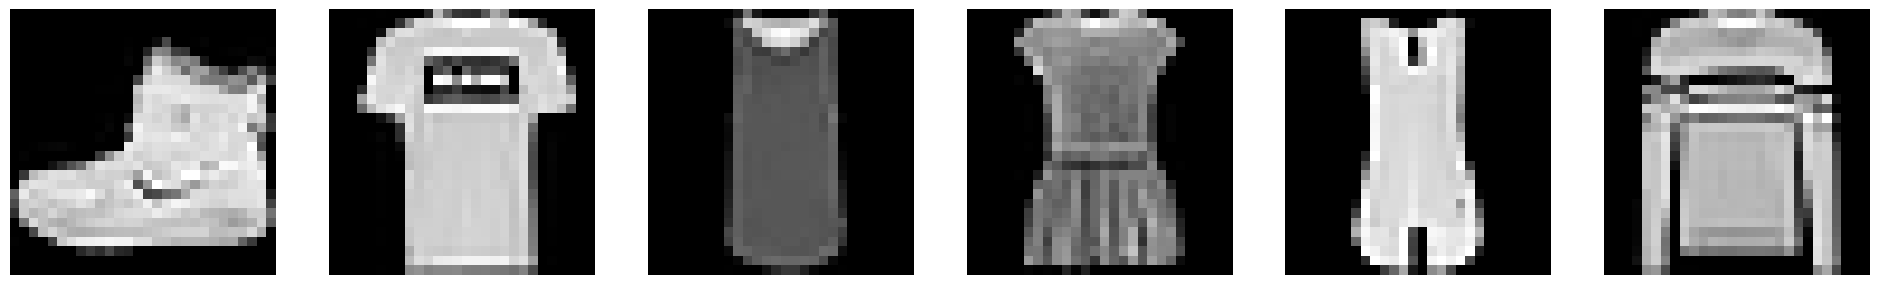

In [2]:
def prepare_data(batch_size=128):
    """Load and prepare Fashion-MNIST dataset"""
    
    # Define transforms
    transform = transforms.Compose([
        transforms.ToTensor(),  # Converts to tensor and scales to [0, 1]
    ])
    
    # Load datasets with transforms
    train_dataset = datasets.FashionMNIST(root='./dataset', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./dataset', train=False, download=True, transform=transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Load data
train_loader, test_loader = prepare_data(batch_size=512)
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Image shape: {train_loader.dataset[0][0].shape}")

# Print a couple of sample images
plt.figure(figsize=(24, 12))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(train_loader.dataset[i][0].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

## Question 4.3 : Model Architecture

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[400], latent_dim=2):
        """
        VAE with configurable architecture
        Args:
            input_dim: Flattened input dimension (28*28=784 for Fashion-MNIST)
            hidden_dims: List of hidden layer dimensions
            latent_dim: Latent space dimension
        """
        super(VAE, self).__init__()

        if isinstance(hidden_dims, int):
            hidden_dims = [hidden_dims]

        # Encoder layers
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            encoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim

        self.encoder = nn.Sequential(*encoder_layers)
        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # Decoder layers
        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        decoder_layers.append(nn.Sigmoid())

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """Encode input to latent distribution parameters"""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = mu + eps * sigma"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        """Decode latent samples to reconstructed images"""
        return self.decoder(z)

    def forward(self, x):
        """Forward pass through VAE"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

## Question 4.4 : Loss Function

In [ ]:
def vae_loss(reconstruction, original, mu, logvar, beta=1.0):
    """
    Compute VAE loss = Reconstruction loss + beta * KL divergence
    Args:
        reconstruction: Reconstructed images
        original: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence term (for β-VAE)
    """
    # Reconstruction loss (BCE)
    recon_loss = F.binary_cross_entropy(reconstruction, original, reduction='sum')
    
    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss
    total_loss = recon_loss + beta * kl_div
    
    return total_loss, recon_loss, kl_div

### What is FID?

**Fréchet Inception Distance (FID)** is a metric used to evaluate the quality of images generated by generative models. It measures the similarity between the distribution of real images and generated images. Lower FID scores indicate better quality and diversity of generated images.

### How FID Works

FID compares the statistics (mean and covariance) of feature representations extracted from real and generated images:

1. **Feature Extraction**: Extract features from both real and generated images using a pre-trained network
2. **Compute Statistics**: Calculate the mean (μ) and covariance (Σ) for both distributions
3. **Calculate Distance**: Compute the Fréchet distance between the two multivariate Gaussians

### Mathematical Formulation

Given:
- Real images features: $\mathcal{N}(\mu_r, \Sigma_r)$
- Generated images features: $\mathcal{N}(\mu_g, \Sigma_g)$

The FID score is calculated as:

$$\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2})$$

where:
- $\|\mu_r - \mu_g\|^2$ measures the distance between feature means
- $\text{Tr}(\cdot)$ is the trace operation (sum of diagonal elements)
- $(\Sigma_r \Sigma_g)^{1/2}$ is the matrix square root of the product of covariances

### Interpretation

- **Lower FID = Better**: Indicates generated images are closer to real images in feature space
- **FID captures both quality and diversity**: Unlike simple pixel-wise metrics, FID considers the entire distribution

In [5]:
import os
import csv
import cv2
from pathlib import Path
from torchmetrics.image.fid import FrechetInceptionDistance

def compute_fid(model, test_loader, device, num_samples=1000):
    """
    Compute Frechet Inception Distance between real and generated images
    Using torchmetrics FID implementation - memory efficient version
    """
    model.eval()

    fid = FrechetInceptionDistance(feature=64).to(device)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    with torch.no_grad():
        count = 0
        for data, _ in test_loader:
            if count >= num_samples:
                break

            # Only process as many samples as needed
            remaining = num_samples - count
            if data.size(0) > remaining:
                data = data[:remaining]

            data = data.to(device)
            batch_size = data.size(0)

            # Process real images - convert to RGB and update FID incrementally
            real_batch = data.repeat(1, 3, 1, 1)
            real_batch = (real_batch * 255).clamp(0, 255).to(torch.uint8)
            fid.update(real_batch, real=True)

            # Free memory
            del real_batch

            # Process generated images
            data_flat = data.view(-1, 784)
            mu, logvar = model.encode(data_flat)
            z = model.reparameterize(mu, logvar)
            fake = model.decode(z)
            fake_batch = fake.view(-1, 1, 28, 28).repeat(1, 3, 1, 1)
            fake_batch = (fake_batch * 255).clamp(0, 255).to(torch.uint8)
            fid.update(fake_batch, real=False)

            # Free memory
            del fake_batch, data_flat, mu, logvar, z, fake
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            count += batch_size

    fid_score = fid.compute()

    return fid_score.item()


def train_vae(model, train_loader, test_loader, epochs=25, learning_rate=1e-3, beta=1.0,
              hidden_dims=[400], latent_dim=2, frames_dir='frames', results_csv='training_results.csv'):
    """
    Train the VAE model with frame generation and FID computation
    
    Args:
        model: VAE model
        train_loader: Training data loader
        test_loader: Test data loader
        epochs: Number of epochs (default: 25)
        learning_rate: Learning rate (default: 1e-3)
        beta: Beta value for KL divergence
        hidden_dims: Hidden layer dimensions
        latent_dim: Latent dimension
        frames_dir: Base directory for saving frames
        results_csv: CSV file for logging results
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Create directories
    hidden_str = '_'.join(map(str, hidden_dims)) if isinstance(hidden_dims, list) else str(hidden_dims)
    exp_name = f'h{hidden_str}_z{latent_dim}_b{beta}'
    beta_frames_dir = os.path.join(frames_dir, exp_name)
    os.makedirs(beta_frames_dir, exist_ok=True)
    
    # CSV files for logging
    train_csv_path = os.path.join(beta_frames_dir, 'train_metrics.csv')
    
    # Initialize CSV files
    with open(train_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'total_loss', 'recon_loss', 'kl_loss'])
    
    # Loss tracking
    train_losses = {'total': [], 'recon': [], 'kl': []}
    
    # Get sample images for visualization (5 classes, 5 images each)
    # Fashion-MNIST classes: 0=T-shirt, 1=Trouser, 2=Pullover, 3=Dress, 4=Coat, 
    #                        5=Sandal, 6=Shirt, 7=Sneaker, 8=Bag, 9=Ankle boot
    selected_classes = [1, 3, 5, 6, 7]  # Trouser, Dress, Sandal, Shirt, Sneaker
    sample_images = []
    sample_labels_list = []
    samples_per_class = 5
    
    with torch.no_grad():
        class_counts = {cls_idx: 0 for cls_idx in selected_classes}
        for data, labels in test_loader:
            for img, lbl in zip(data, labels):
                if lbl.item() in selected_classes and class_counts[lbl.item()] < samples_per_class:
                    sample_images.append(img)
                    sample_labels_list.append(lbl.item())
                    class_counts[lbl.item()] += 1
            if all(c >= samples_per_class for c in class_counts.values()):
                break
    
    sample_images = torch.stack(sample_images).to(device)
    
    # Fashion-MNIST class names
    class_names_map = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
                      5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
    
    # Progress bar for epochs
    pbar = tqdm(range(epochs), desc=f'Training {exp_name}', position=0, leave=True)
    
    for epoch in pbar:
        # Training phase
        model.train()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        
        for batch_idx, (data, labels) in enumerate(train_loader):
            data = data.view(-1, 784).to(device)
            
            optimizer.zero_grad()
            reconstruction, mu, logvar = model(data)
            loss, recon, kl = vae_loss(reconstruction, data, mu, logvar, beta)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
        
        # Calculate average training losses
        avg_train_loss = total_loss / len(train_loader.dataset)
        avg_train_recon = total_recon / len(train_loader.dataset)
        avg_train_kl = total_kl / len(train_loader.dataset)
        
        train_losses['total'].append(avg_train_loss)
        train_losses['recon'].append(avg_train_recon)
        train_losses['kl'].append(avg_train_kl)
        
        # Log training metrics to CSV
        with open(train_csv_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([epoch+1, avg_train_loss, avg_train_recon, avg_train_kl])
        
        # Update progress bar
        pbar.set_postfix({'Loss': f'{avg_train_loss:.4f}'})
        
        # Save frame per epoch (only for 2D latent space)
        if latent_dim == 2:
            save_latent_frame(model, sample_images, sample_labels_list,
                            beta_frames_dir, epoch, epochs, class_names_map, test_loader)
    
    pbar.close()
    
    # Compute FID score
    print(f"Computing FID score for {exp_name}...")
    fid_score = compute_fid(model, test_loader, device)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"FID Score: {fid_score:.4f}")
    
    # Log results to main CSV
    csv_exists = os.path.exists(results_csv)
    with open(results_csv, 'a', newline='') as f:
        writer = csv.writer(f)
        if not csv_exists:
            writer.writerow(['hidden_dims', 'latent_dim', 'beta', 'final_loss', 'final_recon', 'final_kl', 'fid_score'])
        writer.writerow([hidden_str, latent_dim, beta, 
                        train_losses['total'][-1], 
                        train_losses['recon'][-1], 
                        train_losses['kl'][-1],
                        fid_score])
    
    return train_losses, fid_score


def save_latent_frame(model, sample_images, sample_labels, frames_dir, epoch,
                      total_epochs, class_names_map, test_loader):
    """
    Save a frame showing the latent space with all 10 classes plotted
    
    Args:
        model: VAE model
        sample_images: Sample images to visualize (from 5 selected classes)
        sample_labels: Labels for sample images
        frames_dir: Directory to save frames
        epoch: Current epoch
        total_epochs: Total epochs
        class_names_map: Dictionary mapping class indices to names
        test_loader: Test loader to get all classes for plotting
    """
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    import matplotlib
    matplotlib.use('Agg')
    
    model.eval()
    
    with torch.no_grad():
        # Get latent representations for visualization images
        flattened = sample_images.view(-1, 784)
        mu, _ = model.encode(flattened)
        latents = mu.cpu().numpy()
        reconstructions = model.decode(mu)
        reconstructions = reconstructions.view(-1, 28, 28).cpu().numpy()
        
        # Get latent representations for ALL classes
        all_latents = []
        all_labels = []
        for data, labels in test_loader:
            data_flat = data.view(-1, 784).to(device)
            mu_all, _ = model.encode(data_flat)
            all_latents.append(mu_all.cpu().numpy())
            all_labels.append(labels.numpy())
        
        all_latents = np.concatenate(all_latents, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Title
    fig.suptitle(f'Latent Space Evolution | Epoch {epoch+1}/{total_epochs}',
                 fontsize=16, fontweight='bold')
    
    # Plot all 10 classes with different colors
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for cls_label in range(10):
        mask = all_labels == cls_label
        cls_latents = all_latents[mask]
        
        # Plot scatter points for this class
        ax.scatter(cls_latents[:, 0], cls_latents[:, 1],
                  c=[colors[cls_label]], label=class_names_map[cls_label],
                  s=10, alpha=0.5, edgecolors='none')
    
    # Add reconstructed images for the 5 selected classes
    for i, (lat, recon, lbl) in enumerate(zip(latents, reconstructions, sample_labels)):
        imagebox = OffsetImage(recon, zoom=2.5, cmap='gray')
        imagebox.image.axes = ax
        
        ab = AnnotationBbox(imagebox, (lat[0], lat[1]),
                          frameon=True, pad=0.1, zorder=10, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)
    
    ax.set_xlabel('Latent Dimension 1', fontsize=12)
    ax.set_ylabel('Latent Dimension 2', fontsize=12)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save frame
    frame_path = os.path.join(frames_dir, f'frame_epoch{epoch:03d}.png')
    plt.savefig(frame_path, dpi=100)
    plt.close(fig)



def compile_frames_to_video(frames_dir, output_path, fps=5):
    """
    Compile frames from a directory into a video

    Args:
        frames_dir: Directory containing frames
        output_path: Output video path
        fps: Frames per second (default: 5)
    """
    import imageio

    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])

    if not frame_files:
        print(f"No frames found in {frames_dir}")
        return

    frames = []
    for frame_file in frame_files:
        frame_path = os.path.join(frames_dir, frame_file)
        frame = imageio.imread(frame_path)
        frames.append(frame)

    imageio.mimsave(output_path, frames, fps=fps)

### Understanding β-VAE

The **β parameter** in the VAE loss function controls the trade-off between reconstruction quality and latent space regularization:

$$\mathcal{L}_{VAE} = \mathcal{L}_{recon} + \beta \cdot D_{KL}$$

#### Impact of Different Beta Values

**1. Low β (β = 0.1, 0.5)**
- **Reconstruction-focused**: The model prioritizes reconstructing inputs accurately
- **Weak regularization**: Less constraint on the latent space structure
- **Expected FID**: Higher scores due to less structured latent space

**2. Standard β (β = 1.0)**
- **Balanced approach**: Equal weight to reconstruction and KL divergence
- **Standard VAE**: This is the original VAE formulation by Kingma & Welling
- **Latent space**: Reasonably continuous and well-structured
- **Expected FID**: Moderate scores with good reconstruction-generation balance

**3. High β (β = 10.0, 15.0)**
- **Regularization-focused**: Strong emphasis on latent space structure
- **Expected FID**: Lower scores potentially, as the model better matches the prior distribution

### Architecture Variations

**1. Single Hidden Layer (h400_z2)**
- Simple architecture with 400 hidden units
- Fewer parameters, faster training

**2. Two Hidden Layers (h400_200_z2)**
- Deeper network with progressive dimension reduction: 784 → 400 → 200 → 2
- More expressive model
- Can capture more complex features
- Better reconstruction quality expected

**3. Higher Latent Dimension (h400_z20)**
- 20-dimensional latent space vs 2D
- More capacity to encode information
- Better reconstruction possible

In [6]:
def get_latent_representations(model, data_loader, num_samples=5000):
    """Extract latent representations for visualization"""
    model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        for i, (data, label) in enumerate(data_loader):
            if len(latents) * data.size(0) >= num_samples:
                break
            data = data.view(-1, 784).to(device)
            mu, _ = model.encode(data)
            latents.append(mu.cpu().numpy())
            labels.append(label.numpy())
    
    latents = np.concatenate(latents, axis=0)[:num_samples]
    labels = np.concatenate(labels, axis=0)[:num_samples]
    return latents, labels


# Create frames directory
frames_base_dir = 'frames'
os.makedirs(frames_base_dir, exist_ok=True)

# Define all experiments to run
experiments = [
    # Different beta values with base architecture
    {'hidden_dims': [400], 'latent_dim': 2, 'beta': 0.1},
    {'hidden_dims': [400], 'latent_dim': 2, 'beta': 0.5},
    {'hidden_dims': [400], 'latent_dim': 2, 'beta': 1.0},
    {'hidden_dims': [400], 'latent_dim': 2, 'beta': 10.0},
    {'hidden_dims': [400], 'latent_dim': 2, 'beta': 15.0},
    # Different architectures
    {'hidden_dims': [400, 200], 'latent_dim': 2, 'beta': 1.0},
    {'hidden_dims': [400], 'latent_dim': 20, 'beta': 1.0},
]

results = {}
results_csv = 'training_results.csv'

for exp in experiments:
    hidden_dims = exp['hidden_dims']
    latent_dim = exp['latent_dim']
    beta = exp['beta']
    
    hidden_str = '_'.join(map(str, hidden_dims))
    exp_name = f'h{hidden_str}_z{latent_dim}_b{beta}'
    
    print(f"\n{'='*70}")
    print(f"Experiment: {exp_name}")
    print(f"  Hidden layers: {hidden_dims}")
    print(f"  Latent dimension: {latent_dim}")
    print(f"  Beta: {beta}")
    print(f"{'='*70}\n")
    
    # Create model
    model = VAE(input_dim=784, hidden_dims=hidden_dims, latent_dim=latent_dim).to(device)
    
    # Train model
    train_losses, fid_score = train_vae(
        model,
        train_loader,
        test_loader,
        epochs=25,
        learning_rate=1e-3,
        beta=beta,
        hidden_dims=hidden_dims,
        latent_dim=latent_dim,
        frames_dir=frames_base_dir,
        results_csv=results_csv
    )
    
    # Get latent representations
    latents, labels = get_latent_representations(model, test_loader)
    
    # Store results
    results[exp_name] = {
        'model': model,
        'latents': latents,
        'labels': labels,
        'train_losses': train_losses,
        'fid_score': fid_score,
        'config': exp
    }
    
    # Compile video if 2D latent space
    if latent_dim == 2:
        frames_dir = os.path.join(frames_base_dir, exp_name)
        video_filename = exp_name.replace('.', '_') + '.mp4'
        video_path = video_filename
        print(f"\nCompiling video for {exp_name}...")
        compile_frames_to_video(frames_dir, video_path, fps=5)
        print(f"Video saved: {video_path}")
    
    print(f"\nCompleted: {exp_name}")
    print(f"  Final Loss: {train_losses['total'][-1]:.4f}")
    print(f"  FID Score: {fid_score:.4f}\n")

# Display results summary
print_separator()
print("Results Summary")
print(f"{'Experiment':<30} {'Final Loss':<15} {'FID Score':<15}")
print("-"*70)
for exp_name, res in results.items():
    print(f"{exp_name:<30} {res['train_losses']['total'][-1]:<15.4f} {res['fid_score']:<15.4f}")
print("="*70)


Experiment: h400_z2_b0.1
  Hidden layers: [400]
  Latent dimension: 2
  Beta: 0.1



Training h400_z2_b0.1: 100%|██████████| 25/25 [03:09<00:00,  7.60s/it, Loss=254.7358]


Computing FID score for h400_z2_b0.1...
FID Score: 0.3415

Compiling video for h400_z2_b0.1...
Video saved: h400_z2_b0_1.mp4

Completed: h400_z2_b0.1
  Final Loss: 254.7358
  FID Score: 0.3415


Experiment: h400_z2_b0.5
  Hidden layers: [400]
  Latent dimension: 2
  Beta: 0.5



Training h400_z2_b0.5: 100%|██████████| 25/25 [03:22<00:00,  8.10s/it, Loss=259.0032]


Computing FID score for h400_z2_b0.5...
FID Score: 0.3656

Compiling video for h400_z2_b0.5...
Video saved: h400_z2_b0_5.mp4

Completed: h400_z2_b0.5
  Final Loss: 259.0032
  FID Score: 0.3656


Experiment: h400_z2_b1.0
  Hidden layers: [400]
  Latent dimension: 2
  Beta: 1.0



...

Computing FID score for h400_z2_b15.0...
FID Score: 0.5118

Compiling video for h400_z2_b15.0...
Video saved: h400_z2_b15_0.mp4

Completed: h400_z2_b15.0
  Final Loss: 317.4325
  FID Score: 0.5118


Experiment: h400_200_z2_b1.0
  Hidden layers: [400, 200]
  Latent dimension: 2
  Beta: 1.0



Training h400_200_z2_b1.0: 100%|██████████| 25/25 [03:32<00:00,  8.49s/it, Loss=257.0991]


Computing FID score for h400_200_z2_b1.0...
FID Score: 0.3350

Compiling video for h400_200_z2_b1.0...
Video saved: h400_200_z2_b1_0.mp4

Completed: h400_200_z2_b1.0
  Final Loss: 257.0991
  FID Score: 0.3350


Experiment: h400_z20_b1.0
  Hidden layers: [400]
  Latent dimension: 20
  Beta: 1.0



Training h400_z20_b1.0: 100%|██████████| 25/25 [02:50<00:00,  6.82s/it, Loss=242.4114]


Computing FID score for h400_z20_b1.0...
FID Score: 0.2271

Completed: h400_z20_b1.0
  Final Loss: 242.4114
  FID Score: 0.2271

Results Summary
Experiment                     Final Loss      FID Score      
----------------------------------------------------------------------
h400_z2_b0.1                   254.7358        0.3415         
h400_z2_b0.5                   259.0032        0.3656         
h400_z2_b1.0                   262.4044        0.3784         
h400_z2_b10.0                  301.7237        0.4531         
h400_z2_b15.0                  317.4325        0.5118         
h400_200_z2_b1.0               257.0991        0.3350         
h400_z20_b1.0                  242.4114        0.2271         


In [7]:
# Plot loss curves for all experiments
fig, axes = plt.subplots(len(experiments), 3, figsize=(20, 5*len(experiments)))
if len(experiments) == 1:
    axes = axes.reshape(1, -1)

for idx, exp_name in enumerate(results.keys()):
    train_losses = results[exp_name]['train_losses']
    
    # Total loss
    axes[idx, 0].plot(train_losses['total'], linewidth=2, color='blue')
    axes[idx, 0].set_xlabel('Epoch', fontsize=12)
    axes[idx, 0].set_ylabel('Loss', fontsize=12)
    axes[idx, 0].set_title(f'Total Loss - {exp_name}', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Reconstruction loss
    axes[idx, 1].plot(train_losses['recon'], linewidth=2, color='orange')
    axes[idx, 1].set_xlabel('Epoch', fontsize=12)
    axes[idx, 1].set_ylabel('Loss', fontsize=12)
    axes[idx, 1].set_title(f'Reconstruction Loss - {exp_name}', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)
    
    # KL Divergence
    axes[idx, 2].plot(train_losses['kl'], linewidth=2, color='green')
    axes[idx, 2].set_xlabel('Epoch', fontsize=12)
    axes[idx, 2].set_ylabel('Loss', fontsize=12)
    axes[idx, 2].set_title(f'KL Divergence - {exp_name}', fontsize=12, fontweight='bold')
    axes[idx, 2].grid(True, alpha=0.3)

plt.suptitle('Training Curves for All Experiments', fontsize=18, fontweight='bold', y=1.00)
add_username()
plt.tight_layout()
plt.savefig('all_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLoss curves saved to 'all_loss_curves.png'")

# Visualize latent space for 2D experiments
latent_2d_experiments = [k for k, v in results.items() if v['config']['latent_dim'] == 2]

if latent_2d_experiments:
    num_exps = len(latent_2d_experiments)
    fig, axes = plt.subplots(1, num_exps, figsize=(7*num_exps, 6))
    if num_exps == 1:
        axes = [axes]
    
    class_names_map = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
                      5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for i, exp_name in enumerate(latent_2d_experiments):
        latents = results[exp_name]['latents']
        labels = results[exp_name]['labels']
        
        # Plot all 10 classes
        for cls_idx in range(10):
            mask = labels == cls_idx
            axes[i].scatter(latents[mask, 0], latents[mask, 1],
                          c=[colors[cls_idx]], alpha=0.5, label=class_names_map[cls_idx], s=10)
        
        axes[i].set_xlabel('Latent Dimension 1', fontsize=12)
        axes[i].set_ylabel('Latent Dimension 2', fontsize=12)
        axes[i].set_title(exp_name, fontweight='bold', fontsize=12)
        axes[i].legend(fontsize=9, ncol=2, loc='upper right')
        axes[i].grid(True, alpha=0.3)
    
    add_username()
    plt.tight_layout()
    plt.savefig('latent_space_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Latent space comparison saved to 'latent_space_comparison.png'")


Loss curves saved to 'all_loss_curves.png'
Latent space comparison saved to 'latent_space_comparison.png'


In [8]:
def visualize_reconstruction(model, test_loader, num_images=8, title_suffix=""):
    """Visualize original vs reconstructed images"""
    model.eval()
    data, _ = next(iter(test_loader))
    data = data[:num_images].to(device)
    
    with torch.no_grad():
        flattened = data.view(-1, 784)
        reconstruction, _, _ = model(flattened)
        reconstruction = reconstruction.view(-1, 28, 28)
    
    # Plot original and reconstructed images
    plt.figure(figsize=(16, 4))
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i+1)
        plt.imshow(data[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title('Original', fontsize=10)
        
        # Reconstructed
        plt.subplot(2, num_images, num_images+i+1)
        plt.imshow(reconstruction[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title('Reconstructed', fontsize=10)
    
    plt.suptitle(f'Original vs Reconstructed Images{title_suffix}', fontsize=14, fontweight='bold')
    add_username()
    plt.tight_layout()
    plt.show()

# Find best model (lowest FID score)
best_exp_name = min(results.keys(), key=lambda k: results[k]['fid_score'])
best_model = results[best_exp_name]['model']

print_separator()
print(f"Visualizing Reconstruction (Best Model: {best_exp_name})")
print(f"FID Score: {results[best_exp_name]['fid_score']:.4f}")
visualize_reconstruction(best_model, test_loader, title_suffix=f" - {best_exp_name}")

Visualizing Reconstruction (Best Model: h400_z20_b1.0)
FID Score: 0.2271


In [9]:
def generate_samples(model, num_samples=16, latent_dim=2, title_suffix=""):
    """Generate new samples from random latent vectors"""
    model.eval()
    with torch.no_grad():
        # Sample from standard normal
        z = torch.randn(num_samples, latent_dim).to(device)
        samples = model.decode(z)
        samples = samples.view(-1, 28, 28)
    
    # Plot generated samples
    plt.figure(figsize=(12, 12))
    for i in range(num_samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i].cpu().numpy(), cmap='gray')
        plt.axis('off')
    
    plt.suptitle(f'Generated Samples from N(0,I){title_suffix}', fontsize=14, fontweight='bold')
    add_username()
    plt.tight_layout()
    plt.show()
    
    return samples

print_separator()
print(f"Generating samples from latent space (Best Model: {best_exp_name})")
best_latent_dim = results[best_exp_name]['config']['latent_dim']
generated = generate_samples(best_model, num_samples=16, latent_dim=best_latent_dim, title_suffix=f" - {best_exp_name}")

Generating samples from latent space (Best Model: h400_z20_b1.0)


### Effect of Varying Latent Space Parameters

In this section, we explore how varying the standard deviation (σ) of the latent space affects the generated samples, while keeping the mean (μ) fixed at 0. This experiment helps us understand:

1. **Low σ (0.1)**: Samples are drawn from a tight distribution around the origin, resulting in less diversity and more similar-looking outputs.
2. **Medium σ (0.5)**: Moderate diversity in samples, balancing between variety and quality.
3. **High σ (1.0)**: Standard normal distribution - maximum diversity but potentially lower quality as samples may be drawn from regions of latent space not well-represented in training data.

This demonstrates the importance of the KL divergence term in VAE training, which encourages the learned latent distributions to match N(0,1).

In [10]:
def generate_with_varying_sigma(model, sigma_values=[0.1, 0.5, 1.0], num_samples=8, latent_dim=2):
    """Generate samples with fixed mu=0 and varying sigma"""
    model.eval()
    results_dict = {}
    
    plt.figure(figsize=(16, 4*len(sigma_values)))
    
    for idx, sigma in enumerate(sigma_values):
        with torch.no_grad():
            # Fixed mu=0, varying sigma
            mu = torch.zeros(num_samples, latent_dim).to(device)
            z = mu + sigma * torch.randn_like(mu)
            samples = model.decode(z)
            samples = samples.view(-1, 28, 28)
            results_dict[sigma] = samples
        
        # Plot samples for each sigma
        for i in range(num_samples):
            plt.subplot(len(sigma_values), num_samples, idx*num_samples + i + 1)
            plt.imshow(samples[i].cpu().numpy(), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.ylabel(f'σ={sigma}', fontsize=14, fontweight='bold', rotation=0, labelpad=40)
    
    plt.suptitle(f'Generated Samples: Fixed μ=0, Varying σ (Model: {best_exp_name})', fontsize=16, fontweight='bold')
    add_username()
    plt.tight_layout()
    plt.savefig('varying_sigma_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return results_dict

sigma_results = generate_with_varying_sigma(best_model, latent_dim=best_latent_dim)
print("Figure saved: varying_sigma_samples.png")

Figure saved: varying_sigma_samples.png


In [ ]:
# Latent Space Interpolation (only for 2D latent spaces)
def interpolate_latent_space(model, class1_idx, class2_idx, num_steps=10):
    """Interpolate between two classes in latent space"""
    model.eval()
    
    # Get sample from each class
    samples = {class1_idx: None, class2_idx: None}
    
    for data, labels in test_loader:
        for img, lbl in zip(data, labels):
            if lbl.item() == class1_idx and samples[class1_idx] is None:
                samples[class1_idx] = img.to(device)
            if lbl.item() == class2_idx and samples[class2_idx] is None:
                samples[class2_idx] = img.to(device)
            if all(v is not None for v in samples.values()):
                break
        if all(v is not None for v in samples.values()):
            break
    
    # Get latent representations
    with torch.no_grad():
        z1, _ = model.encode(samples[class1_idx].view(1, -1))
        z2, _ = model.encode(samples[class2_idx].view(1, -1))
        
        # Interpolate
        alphas = np.linspace(0, 1, num_steps)
        interpolated_images = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            img = model.decode(z_interp)
            interpolated_images.append(img.view(28, 28).cpu().numpy())
    
    # Plot
    class_names_map = {0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress',
                       4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker',
                       8: 'Bag', 9: 'Ankle boot'}
    
    plt.figure(figsize=(20, 3))
    for i, img in enumerate(interpolated_images):
        plt.subplot(1, num_steps, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(f'{class_names_map[class1_idx]}', fontsize=10, fontweight='bold')
        elif i == num_steps - 1:
            plt.title(f'{class_names_map[class2_idx]}', fontsize=10, fontweight='bold')
    
    plt.suptitle(f'Latent Space Interpolation: {class_names_map[class1_idx]} → {class_names_map[class2_idx]}',
                 fontsize=14, fontweight='bold')
    add_username()
    plt.tight_layout()
    plt.savefig(f'interpolation_{class1_idx}_to_{class2_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()


# 2D Latent Space Grid Sampling
def sample_latent_grid(model, grid_size=10, latent_range=3):
    """Sample uniformly from 2D latent space grid"""
    model.eval()
    
    x = np.linspace(-latent_range, latent_range, grid_size)
    y = np.linspace(-latent_range, latent_range, grid_size)
    
    plt.figure(figsize=(15, 15))
    
    with torch.no_grad():
        for i, yi in enumerate(reversed(y)):
            for j, xj in enumerate(x):
                z = torch.tensor([[xj, yi]], dtype=torch.float32).to(device)
                img = model.decode(z)
                img = img.view(28, 28).cpu().numpy()
                
                plt.subplot(grid_size, grid_size, i * grid_size + j + 1)
                plt.imshow(img, cmap='gray')
                plt.axis('off')
    
    plt.suptitle('2D Latent Space Grid Sampling', fontsize=16, fontweight='bold')
    add_username()
    plt.tight_layout()
    plt.savefig('latent_grid_sampling.png', dpi=150, bbox_inches='tight')
    plt.show()


# Only run these visualizations for 2D latent space models
best_2d_model = None
best_2d_exp = None

for exp_name, res in results.items():
    if res['config']['latent_dim'] == 2:
        if best_2d_model is None or res['fid_score'] < results[best_2d_exp]['fid_score']:
            best_2d_model = res['model']
            best_2d_exp = exp_name

if best_2d_model is not None:
    print("="*70)
    print(f"Additional Visualizations (Best 2D Model: {best_2d_exp})")
    print("="*70)
    
    # Interpolations between different class pairs
    interpolate_latent_space(best_2d_model, class1_idx=1, class2_idx=7, num_steps=12)
    interpolate_latent_space(best_2d_model, class1_idx=5, class2_idx=6, num_steps=12)
    
    # Grid sampling
    sample_latent_grid(best_2d_model, grid_size=15, latent_range=3)
    
    print("\nAll visualizations completed!")
else:
    print("No 2D latent space models found for additional visualizations.")

Additional Visualizations (Best 2D Model: h400_200_z2_b1.0)

All visualizations completed!
